## Intro

This notebook downloads wind and solar resource data from ERA5 using Atlite for a given region and outputs to `{identifier}_solar_power_profile.csv` and `{identifier}_wind_power_profile.csv`, as capacity factor time-series for each location in the region at 0.25 degree resolution. Land border and Exclusive Economic Zone (EEZ) datasets need to be downloaded before running to define a region. Then, land availability is computed downloading the MODIS land cover dataset, UNEP protected areas dataset and STRP elevation data to exclude sloping land. This outputs to `{identifier}_renewables_land_cover_with_offshore.csv` with land availability for each location at 0.25 degree resolution. Maps are plotted at each step to check outputs. 

## Environment Requirement

This notebook requires the `plot-env` environment to run. Please ensure you have the environment set up with the necessary dependencies before running the cells in this notebook. This separate environment is necessary as calliope-env loads a different version of plotly. # TODO: adjust map plotting functions or packages so only a single environment is needed. 

In [1]:
import atlite
import geopandas as gpd
import plotly.graph_objects as go
from shapely.geometry import Point
import os
import pycountry
import numpy as np

# Function to get the bounding box of a country using the correct shapefile
def get_country_bbox(country, land_shapefile_path, eez_shapefile_path, include_offshore):
    if include_offshore:
        gdf = gpd.read_file(eez_shapefile_path)
        country_gdf = gdf[(gdf['TERRITORY1'] == country) | (gdf['TERRITORY2'] == country)]
    else:
        gdf = gpd.read_file(land_shapefile_path)
        country_gdf = gdf[gdf['NAME'] == country]

    if not country_gdf.empty:
        bounds = country_gdf.total_bounds  # [minx, miny, maxx, maxy]
        return bounds[1], bounds[3], bounds[0], bounds[2]  # [lat_min, lat_max, lon_min, lon_max]
    else:
        raise ValueError(f"Could not find bounding box for country: {country}")

# Function to plot the bounding box against country borders and maritime areas
def plot_cutout_area(bbox, country, land_shapefile_path, eez_shapefile_path, include_offshore):
    lat_min, lat_max, lon_min, lon_max = bbox
    center_lat = (lat_min + lat_max) / 2
    center_lon = (lon_min + lon_max) / 2

    boundary_traces = []

    if isinstance(country, str):  # Check if the input is a country name
        if include_offshore:
            gdf = gpd.read_file(eez_shapefile_path)
            country_gdf = gdf[(gdf['TERRITORY1'] == country) | (gdf['TERRITORY2'] == country)]
        else:
            gdf = gpd.read_file(land_shapefile_path)
            country_gdf = gdf[gdf['NAME'] == country]

        country_gdf = country_gdf.to_crs(epsg=4326)  # Ensure CRS is in WGS84 for Plotly

        # Create Scattermapbox traces for country and EEZ boundaries
        for _, row in country_gdf.iterrows():
            if isinstance(row.geometry, Point):
                continue
            if row.geometry.geom_type == 'Polygon':
                lon, lat = row.geometry.exterior.coords.xy
                boundary_traces.append(go.Scattermapbox(
                    lon=list(lon),
                    lat=list(lat),
                    mode='lines',
                    line=dict(width=1, color='blue'),
                    showlegend=False,
                    name='Boundary' if not include_offshore else 'EEZ'
                ))
            elif row.geometry.geom_type == 'MultiPolygon':
                for polygon in row.geometry.geoms:
                    lon, lat = polygon.exterior.coords.xy
                    boundary_traces.append(go.Scattermapbox(
                        lon=list(lon),
                        lat=list(lat),
                        mode='lines',
                        line=dict(width=1, color='blue'),
                        showlegend=False,
                        name='Boundary' if not include_offshore else 'EEZ'
                    ))

    # Add the country and EEZ boundaries to the plot
    fig = go.Figure(boundary_traces)

    # Add the cutout rectangle as a trace
    cutout_trace = go.Scattermapbox(
        lon=[lon_min, lon_max, lon_max, lon_min, lon_min],
        lat=[lat_min, lat_min, lat_max, lat_max, lat_min],
        mode='lines',
        line=dict(width=2, color='red'),
        name='Cutout Area'
    )
    fig.add_trace(cutout_trace)

    # Update layout to use mapbox with the same style as the complex plots
    fig.update_layout(
        title=f'Cutout Area vs. {"EEZ" if include_offshore else "Country Borders"} in {country}',
        mapbox=dict(
            style='carto-positron',  # Ensures map background is visible
            center=dict(lat=center_lat, lon=center_lon),
            zoom=5,  # Adjust zoom level as needed
        ),
        width=1000,  # Set the width of the figure
        height=800,  # Set the height of the figure
    )

    # Adjust view to have moderate margins around the cutout area
    lat_margin = (lat_max - lat_min) * 0.1  # 10% buffer
    lon_margin = (lon_max - lon_min) * 0.1  # 10% buffer
    fig.update_layout(
        mapbox=dict(
            center=dict(lat=center_lat, lon=center_lon),
            zoom=5  # Set zoom to keep a closer view by default
        ),
        margin=dict(l=10, r=10, t=40, b=10)
    )
    fig.show()

# Function to create and prepare the cutout for a specified time range
def create_cutout(bbox, identifier, start_date, end_date, save_path):
    cutout = atlite.Cutout(
        path=os.path.join(save_path, f"{identifier}_{start_date}_to_{end_date}.nc"),
        module="era5",
        x=slice(bbox[2], bbox[3]),  # lon_min, lon_max
        y=slice(bbox[0], bbox[1]),  # lat_min, lat_max
        time=slice(start_date, end_date)  # Use slice for the time period
    )
    print(cutout)
    cutout.prepare()
    return cutout

# Function to get ISO3 code of a country
def get_iso3_code(country_name):
    country = pycountry.countries.get(name=country_name)
    if country:
        return country.alpha_3
    else:
        raise ValueError(f"Could not find ISO3 code for country: {country_name}")

# Define your parameters
country = "Ukraine"
identifier = get_iso3_code(country)
land_shapefile_path = "../data_prep/data/ne_10m_admin_0_map_units/ne_10m_admin_0_map_units.shp"
eez_shapefile_path = "../data_prep/data/EEZ_land_union_v3_202003/EEZ_Land_v3_202030.shp"
include_offshore = True

# Get the bounding box for the country
bbox = get_country_bbox(country, land_shapefile_path, eez_shapefile_path, include_offshore)

print(bbox)

# Alternatively, you can define an arbitrary bounding box like this:
# bbox = (lat_min, lat_max, lon_min, lon_max)
# Example: bbox = (43.0, 50.0, 10.0, 30.0)
# identifier = "custom_box"

start_date = ["2023-01-01", "2023-02-01", "2023-03-01", "2023-04-01", "2023-05-01","2023-06-01", "2023-07-01", "2023-08-01", "2023-09-01", "2023-10-01", "2023-11-01", "2023-12-01"]
end_date = ["2023-01-31","2023-02-28", "2023-03-31", "2023-04-30", "2023-05-31","2023-06-30", "2023-07-31", "2023-08-31", "2023-09-30", "2023-10-31", "2023-11-30", "2023-12-31"]
save_path = "./era5_data"

# Ensure the save path exists
os.makedirs(save_path, exist_ok=True)

# Plot the cutout area
plot_cutout_area(bbox, country, land_shapefile_path, eez_shapefile_path, include_offshore)


(43.18805555555582, 52.384014129448474, 22.13846564337473, 40.21973443049956)


C:\Users\Benhd\AppData\Local\Temp\ipykernel_21604\3710219901.py:59: DeprecationWarning: *scattermapbox* is deprecated! Use *scattermap* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  boundary_traces.append(go.Scattermapbox(
C:\Users\Benhd\AppData\Local\Temp\ipykernel_21604\3710219901.py:72: DeprecationWarning:

*scattermapbox* is deprecated! Use *scattermap* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/



In [2]:
# Create and prepare the cutout for the specified time range
cutouts = []
i=1
for start, end in zip(start_date, end_date):
    if i==1:
        cutout= create_cutout(bbox, identifier, start, end, save_path)
        i+=1
    else:
        cutout_aux = create_cutout(bbox, identifier, start, end, save_path)
        cutout = cutout.merge(cutout_aux)
        i+=1
# Check your request status at https://cds.climate.copernicus.eu/requests?tab=all

<Cutout "UKR_2023-01-01_to_2023-01-31">
 x = 22.25 ⟷ 40.00, dx = 0.25
 y = 43.25 ⟷ 52.25, dy = 0.25
 time = 2023-01-01 ⟷ 2023-01-31, dt = h
 module = era5
 prepared_features = []


a23492d59fccfb4cb3c8e291196a3c60.grib:   0%|          | 0.00/15.4M [00:00<?, ?B/s]

58b74f214209daefc09c03ae4aa5654.grib:   0%|          | 0.00/21.2M [00:00<?, ?B/s]

911d22e1df4a9d3e789afd69d9d8653a.grib:   0%|          | 0.00/7.91k [00:00<?, ?B/s]

f079ef4f5876aee6f7f6eed9a0039416.grib:   0%|          | 0.00/11.6M [00:00<?, ?B/s]

...

84aa3d8a21a458bf9f4286aa0d828cc2.grib:   0%|          | 0.00/11.6M [00:00<?, ?B/s]

f3212bfb20fd8ef544fbe93d7bd29e16.grib:   0%|          | 0.00/15.4M [00:00<?, ?B/s]

43d7b971e83faa17a0ef328cde8a430a.grib:   0%|          | 0.00/21.2M [00:00<?, ?B/s]

7cdfe8fb614b8f69d8af89877aa9bdb0.grib:   0%|          | 0.00/3.86M [00:00<?, ?B/s]

c:\Users\Benhd\Code\envs\plot-env\Lib\site-packages\atlite\data.py:239: FutureWarning:

In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.

c:\Users\Benhd\Code\envs\plot-env\Lib\site-packages\atlite\data.py:239: FutureWarning:

In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.

c:\Users\Benhd\Code\envs\plot-env\Lib\site-packages\atlite\cutout.py:438: FutureWarning:

In a futur

In [3]:
# Create a uniform layout across the grid squares using default capacity
layout = cutout.uniform_layout()

# Use the grid squares themselves as the shapes
grid_cells = gpd.GeoDataFrame({
    'geometry': [Point(lon, lat).buffer(0.1) for lat in cutout.coords['y'].values for lon in cutout.coords['x'].values],
    'capacity': layout.values.flatten()
})

# Apply the pv() method to get the solar power profile
pv_profile = cutout.pv(
    panel='CSi',
    orientation='latitude_optimal',
    layout=layout,
    shapes=grid_cells.geometry,
    per_unit=True
)

# Apply the wind() method to get the wind power profile
wind_profile = cutout.wind(
    turbine='Vestas_V112_3MW',
    layout=layout,
    shapes=grid_cells.geometry,
    per_unit=True
)

# Convert the profiles to pandas DataFrames
pv_df = pv_profile.to_pandas()
wind_df = wind_profile.to_pandas()

# Ensure that the DataFrames have columns formatted with reduced decimals (0.25-degree resolution)
pv_df.columns = [f"{lat:.2f}_{lon:.2f}" for lat in cutout.coords['y'].values for lon in cutout.coords['x'].values]
wind_df.columns = pv_df.columns  # Ensure both DataFrames have the same columns

# --- Now proceed to filter the DataFrames based on the grid points within the country ---

# Function to generate grid points within bounding box at 0.25-degree resolution and filter points inside the country or its EEZ
def generate_grid_points_within_country(country, land_shapefile_path, eez_shapefile_path, include_offshore):
    # Get the bounding box of the country using the original get_country_bbox function
    bbox = get_country_bbox(country, land_shapefile_path, eez_shapefile_path, include_offshore)
    lat_min, lat_max, lon_min, lon_max = bbox

    # Generate grid points at 0.25-degree resolution
    lat_points = np.arange(np.floor(lat_min), np.ceil(lat_max) + 0.25, 0.25)
    lon_points = np.arange(np.floor(lon_min), np.ceil(lon_max) + 0.25, 0.25)
    all_grid_points = [(lat, lon) for lat in lat_points for lon in lon_points]

    # Read the shapefile depending on whether offshore areas are included
    if include_offshore:
        country_gdf = gpd.read_file(eez_shapefile_path)
        country_gdf = country_gdf[(country_gdf['TERRITORY1'] == country) | (country_gdf['TERRITORY2'] == country)]
    else:
        country_gdf = gpd.read_file(land_shapefile_path)
        country_gdf = country_gdf[country_gdf['NAME'] == country]

    # Ensure CRS is in WGS84 to match the coordinates system
    country_gdf = country_gdf.to_crs(epsg=4326)

    # Filter grid points to keep only those within the country or EEZ boundaries
    points_within_country = [
        (lat, lon) for lat, lon in all_grid_points
        if country_gdf.contains(Point(lon, lat)).any()
    ]
    
    return points_within_country, bbox

# Generate grid points within the bounding box of the country and filter based on country boundaries
filtered_grid_points, bbox = generate_grid_points_within_country(
    country, land_shapefile_path, eez_shapefile_path, include_offshore
)

# Format the filtered grid points as 'lat_lon' with reduced decimals
filtered_lon_lat = [f"{lat:.2f}_{lon:.2f}" for lat, lon in filtered_grid_points]

# Filter the DataFrame columns by their names matching the filtered lon/lat points
pv_df_filtered = pv_df.loc[:, pv_df.columns.intersection(filtered_lon_lat)]
wind_df_filtered = wind_df.loc[:, wind_df.columns.intersection(filtered_lon_lat)]

# Sort the columns in increasing order of latitude and longitude
pv_df_filtered = pv_df_filtered.reindex(sorted(pv_df_filtered.columns, key=lambda x: tuple(map(float, x.split('_')))), axis=1)
wind_df_filtered = wind_df_filtered.reindex(sorted(wind_df_filtered.columns, key=lambda x: tuple(map(float, x.split('_')))), axis=1)

# Save the filtered profiles to CSV files
pv_csv_path = os.path.join(save_path, f"{identifier}_solar_power_profile.csv")
wind_csv_path = os.path.join(save_path, f"{identifier}_wind_power_profile.csv")

pv_df_filtered.to_csv(pv_csv_path, index_label="datetime")
wind_df_filtered.to_csv(wind_csv_path, index_label="datetime")


c:\Users\Benhd\Code\envs\plot-env\Lib\site-packages\xarray\util\deprecation_helpers.py:144: PerformanceWarning:

Reshaping is producing a large chunk. To accept the large
chunk and silence this warning, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': False}):
    ...     array.reshape(shape)

To avoid creating the large chunks, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': True}):
    ...     array.reshape(shape)Explictly passing ``limit`` to ``reshape`` will also silence this warning
    >>> array.reshape(shape, limit='128 MiB')

c:\Users\Benhd\Code\envs\plot-env\Lib\site-packages\atlite\resource.py:90: FutureWarning:

'add_cutout_windspeed' for wind turbine
power curves will default to True in atlite relase v0.2.15.



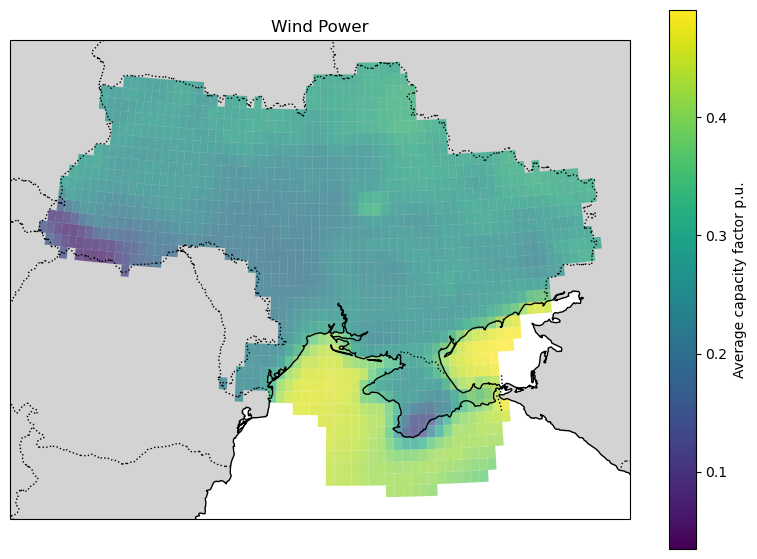

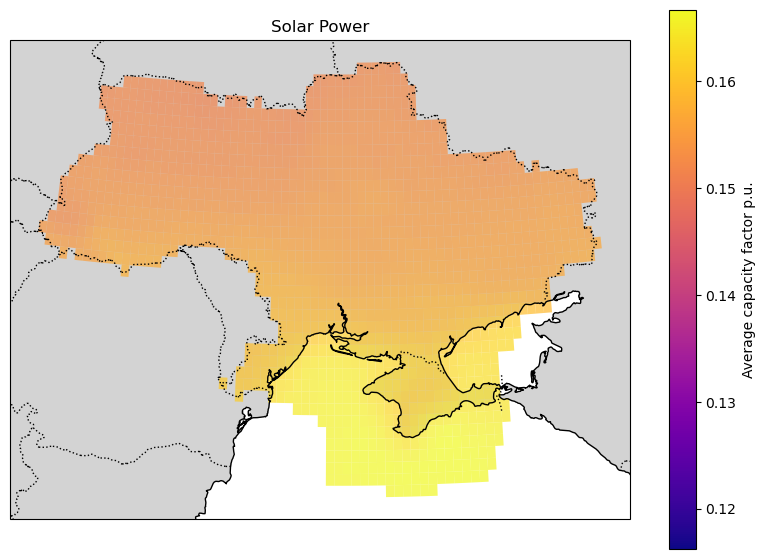

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from matplotlib.patches import Rectangle
import cartopy.feature as cfeature

# Function to get the average values from the CSV files
def get_avg_values(power_file):
    power_df = pd.read_csv(power_file, index_col=0, parse_dates=True)
    avg_df = power_df.mean(axis=0).reset_index()
    avg_df.columns = ['location', 'avg_power']
    avg_df[['lat', 'lon']] = avg_df['location'].str.split('_', expand=True).astype(float)
    return avg_df

# Define the paths to the power profile files (0.25-degree resolution)
save_path = './era5_data'
iso3_code = 'UKR'
wind_power_file = os.path.join(save_path, f'{iso3_code}_wind_power_profile.csv')
solar_power_file = os.path.join(save_path, f'{iso3_code}_solar_power_profile.csv')

# Get the average values for wind and solar power
wind_avg = get_avg_values(wind_power_file)
solar_avg = get_avg_values(solar_power_file)

# Function to plot the data using Cartopy with Lambert Azimuthal Equal Area projection
def plot_static_map(df, title, cmap_name, filename):
    # Set up the map projection (Lambert Azimuthal Equal Area)
    projection = ccrs.LambertAzimuthalEqualArea(central_latitude=df['lat'].mean(), central_longitude=df['lon'].mean())
    
    # Create figure and axis
    fig, ax = plt.subplots(figsize=(10, 7), subplot_kw={'projection': projection})

    # Add coastlines, borders, and land features
    ax.add_feature(cfeature.COASTLINE)
    ax.add_feature(cfeature.BORDERS, linestyle=':')
    ax.add_feature(cfeature.LAND, facecolor='lightgray')

    # Use the new colormap API introduced in Matplotlib 3.7+
    cmap = plt.colormaps.get_cmap(cmap_name)

    # Loop over the DataFrame rows to plot each grid cell
    for i, row in df.iterrows():
        lat = row['lat']
        lon = row['lon']
        avg_power = row['avg_power']
        
        
        # Define the rectangle for the 0.25-degree grid cell
        rect = Rectangle(
            (lon - 0.125, lat - 0.125), 0.25, 0.25,  # lon_min, lat_min, width, height
            facecolor=cmap(avg_power / df['avg_power'].max()),  # Color based on avg power
            edgecolor='none',
            alpha=0.7,
            transform=ccrs.PlateCarree()  # Use PlateCarree for accurate placement
        )
        ax.add_patch(rect)

    # Add colorbar
    scatter = ax.scatter(df['lon'], df['lat'], c=df['avg_power'], cmap=cmap_name, s=0, transform=ccrs.PlateCarree())  # Dummy scatter for colorbar
    cbar = plt.colorbar(scatter, ax=ax, orientation="vertical")
    cbar.set_label('Average capacity factor p.u.')
    
    # Set title
    plt.title(title)

    # Save the figure as PNG
    plt.savefig(f'{filename}.png')
    plt.show()

# Plot the wind power map
plot_static_map(wind_avg, 'Wind Power', 'viridis', 'wind_power_map_1')

# Plot the solar power map
plot_static_map(solar_avg, 'Solar Power', 'plasma', 'solar_power_map_1')


In [5]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Polygon

def load_pv_power_profile_to_geodataframe(pv_csv_path):
    # Load the CSV
    pv_df = pd.read_csv(pv_csv_path, index_col='datetime')
    
    # Extract lat/lon from column names
    locations = pv_df.columns
    coordinates = [tuple(map(float, loc.split('_'))) for loc in locations]
    
    # Create polygons for each grid cell (assuming 0.25-degree resolution)
    def create_grid_polygon(lat, lon, resolution=0.25):
        half_res = resolution / 2.0
        # Create a polygon for the grid cell (simple square)
        return Polygon([
            (lon - half_res, lat - half_res),
            (lon + half_res, lat - half_res),
            (lon + half_res, lat + half_res),
            (lon - half_res, lat + half_res)
        ])

    # Create a list of polygons for each location
    polygons = [create_grid_polygon(lat, lon) for lat, lon in coordinates]
    
    # Create a GeoDataFrame
    geo_df = gpd.GeoDataFrame({
        'location': locations,
        'geometry': polygons
    }, crs="EPSG:4326")  # Assuming WGS84 coordinates

    return geo_df

# Example usage
pv_csv_path = os.path.join(save_path, f"{identifier}_solar_power_profile.csv")
# Use the function to load the solar power profile CSV into a GeoDataFrame
pv_geodf = load_pv_power_profile_to_geodataframe(pv_csv_path)

# Now you can explore the GeoDataFrame
pv_geodf.head()


,location,geometry
0,43.25_33.25,"POLYGON ((33.125 43.125, 33.375 43.125, 33.375..."
1,43.25_33.50,"POLYGON ((33.375 43.125, 33.625 43.125, 33.625..."
2,43.25_33.75,"POLYGON ((33.625 43.125, 33.875 43.125, 33.875..."
3,43.25_34.00,"POLYGON ((33.875 43.125, 34.125 43.125, 34.125..."
4,43.25_34.25,"POLYGON ((34.125 43.125, 34.375 43.125, 34.375..."


In [12]:
import geopandas as gpd

# Reproject the GeoDataFrame to a global equal-area projection (EPSG:6933 - World Cylindrical Equal-Area)
pv_geodf_projected = pv_geodf.to_crs(epsg=6933)

# Add an area column, converting from square meters to square kilometers
pv_geodf_projected['area_km2'] = pv_geodf_projected.geometry.area / 1e6  # Convert from m^2 to km^2

# Reproject back to WGS84 (EPSG:4326) if needed
pv_geodf_with_area = pv_geodf_projected.to_crs(epsg=4326)

# Print the GeoDataFrame with the area column to verify
pv_geodf_with_area[['location', 'area_km2', 'geometry']].head()


,location,area_km2,geometry
0,43.25_33.25,563.886569,"POLYGON ((33.125 43.125, 33.375 43.125, 33.375..."
1,43.25_33.50,563.886569,"POLYGON ((33.375 43.125, 33.625 43.125, 33.625..."
2,43.25_33.75,563.886569,"POLYGON ((33.625 43.125, 33.875 43.125, 33.875..."
3,43.25_34.00,563.886569,"POLYGON ((33.875 43.125, 34.125 43.125, 34.125..."
4,43.25_34.25,563.886569,"POLYGON ((34.125 43.125, 34.375 43.125, 34.375..."


In [11]:
import ee
import geemap
import geopandas as gpd
from shapely.geometry import Polygon
from tqdm import tqdm  # Import tqdm for progress bar
import os  # Import os to check if file exists
import pandas as pd  # Assuming you need pandas for DataFrame operations

# Define the output file path
identifier = 'UKR'
output_file = f'../data_prep/data/{identifier}_renewables_land_cover.csv'

# Check if the file already exists to skip the Earth Engine process
if os.path.exists(output_file):
    print(f"{output_file} already exists. Skipping Earth Engine processing.")
    # Read in existing file
    pv_geodf_with_area = pd.read_csv(output_file)
else:
    # Authenticate and initialize Earth Engine
    ee.Authenticate()
    ee.Initialize()

    # Load MODIS Land Cover (MCD12Q1) dataset for 2020
    modis_landcover = ee.ImageCollection('MODIS/006/MCD12Q1') \
        .filterDate('2020-01-01', '2020-12-31').first()

    # Load UNEP-WCMC World Database on Protected Areas (WDPA)
    wdpa_polygons = ee.FeatureCollection('WCMC/WDPA/current/polygons')

    # Load Shuttle Radar Topography Mission (SRTM) elevation data and calculate slope
    srtm = ee.Image('USGS/SRTMGL1_003')
    slope = ee.Terrain.slope(srtm)

    # Define land availability factors for each land cover type
    # (Verschuur et al. 2024 supplementary material)
    land_availability_factors = {
        0: 0.0,   # Water
        1: 0.0,   # Evergreen Needleleaf Forest
        2: 0.0,   # Evergreen Broadleaf Forest
        3: 0.0,   # Deciduous Needleleaf Forest
        4: 0.0,   # Deciduous Broadleaf Forest
        5: 0.0,   # Mixed Forests
        6: 0.5,   # Closed Shrublands
        7: 0.5,   # Open Shrublands
        8: 0.2,   # Woody Savannas
        9: 0.2,   # Savannas
        10: 0.2,  # Grasslands
        11: 0.0,  # Permanent Wetlands
        12: 0.05, # Croplands
        13: 0.03, # Urban and Built-up
        14: 0.05, # Cropland/Natural Vegetation Mosaics
        15: 0.0,  # Snow and Ice
        16: 1.0,  # Barren or Sparsely Vegetated
        17: 0.0   # Unclassified
    }

    # Define a function to convert Shapely polygons to Earth Engine polygons
    def shapely_to_ee_polygon(polygon_geometry):
        """Convert a Shapely polygon to an Earth Engine polygon."""
        if polygon_geometry.is_empty:
            raise ee.EEException("Empty geometry.")
        
        # Extract exterior coordinates (outer boundary of the polygon)
        exterior_coords = list(polygon_geometry.exterior.coords)
        
        # Handle polygons with holes (interior rings)
        interiors = [list(interior.coords) for interior in polygon_geometry.interiors]

        # Earth Engine expects coordinates as lists of lists
        ee_polygon = ee.Geometry.Polygon([exterior_coords] + interiors)
        
        return ee_polygon

    # Function to calculate land cover fractions and available land for a given polygon
    def calculate_land_cover_for_polygon(polygon_geometry, modis_image, land_availability_factors):
        try:
            # Convert Shapely polygon to Earth Engine polygon
            ee_polygon = shapely_to_ee_polygon(polygon_geometry)
            
            # Clip the MODIS land cover image to the polygon
            modis_clipped = modis_image.clip(ee_polygon)
            
            # Get the land cover classification
            landcover_classification = modis_clipped.select('LC_Type1')
            
            # Set 'mask' property to 1 for all protected areas
            protected_areas = wdpa_polygons.map(lambda f: f.set('mask', 1))
            
            # Create a raster mask of protected areas
            protected_areas_raster = protected_areas.reduceToImage(
                properties=['mask'],
                reducer=ee.Reducer.first()
            ).clip(ee_polygon).unmask(0).rename('protected_mask')
            
            # Invert the mask: 1 where not protected, 0 where protected
            protected_mask = protected_areas_raster.eq(0)
            
            # Clip and mask the slope image
            slope_clipped = slope.clip(ee_polygon)
            
            # Create a mask for areas with slope <= 15 degrees
            slope_mask = slope_clipped.lte(15)
            
            # Combine the masks: areas not protected and with slope <=15 degrees
            combined_mask = protected_mask.And(slope_mask)
            
            # Apply the combined mask to the land cover classification
            landcover_masked = landcover_classification.updateMask(combined_mask)
            
            # Create a frequency histogram for the land cover types within the polygon
            landcover_histogram = landcover_masked.reduceRegion(
                reducer=ee.Reducer.frequencyHistogram(),
                geometry=ee_polygon,
                scale=500,
                maxPixels=1e13
            ).getInfo().get('LC_Type1', {})
            
            # Calculate total number of pixels in the polygon after masking
            total_pixels = sum(landcover_histogram.values())
            
            if total_pixels == 0:
                # No need to print inside the loop
                return None, 0.0, None
            
            # Calculate land cover fractions, available land fraction, and primary land cover type
            land_cover_fractions = {}
            available_land_fraction = 0
            primary_land_cover_type = None
            max_pixels = 0
            
            for land_type, pixel_count in landcover_histogram.items():
                fraction = pixel_count / total_pixels
                land_cover_fractions[int(land_type)] = fraction
                
                # Calculate available land for this land cover type
                if int(land_type) in land_availability_factors:
                    available_fraction = fraction * land_availability_factors[int(land_type)]
                    available_land_fraction += available_fraction
                
                # Track the primary land cover type (most pixels)
                if pixel_count > max_pixels:
                    primary_land_cover_type = int(land_type)
                    max_pixels = pixel_count
            
            return land_cover_fractions, available_land_fraction, primary_land_cover_type
        
        except ee.EEException as e:
            print(f"Error processing polygon: {e}")
            return None, None, None

    # Initialize new columns for the GeoDataFrame
    pv_geodf_with_area['available_land_fraction'] = 0.0
    pv_geodf_with_area['available_land_area_km2'] = 0.0
    pv_geodf_with_area['primary_land_cover_type'] = None

    # Counter for polygons with no available land
    no_available_land_count = 0

    # Add a progress bar to the loop using tqdm
    for idx, row in tqdm(pv_geodf_with_area.iterrows(), total=len(pv_geodf_with_area), desc="Processing polygons"):
        polygon = row['geometry']
        
        # Calculate land cover fractions, available land, and primary land cover type
        land_cover_fractions, available_land_fraction, primary_land_cover_type = calculate_land_cover_for_polygon(
            polygon, modis_landcover, land_availability_factors)
        
        # Update the GeoDataFrame with these values
        if available_land_fraction is not None:
            pv_geodf_with_area.at[idx, 'available_land_fraction'] = available_land_fraction
            pv_geodf_with_area.at[idx, 'available_land_area_km2'] = row['area_km2'] * available_land_fraction
            pv_geodf_with_area.at[idx, 'primary_land_cover_type'] = primary_land_cover_type
        else:
            pv_geodf_with_area.at[idx, 'available_land_fraction'] = 0.0
            pv_geodf_with_area.at[idx, 'available_land_area_km2'] = 0.0
            pv_geodf_with_area.at[idx, 'primary_land_cover_type'] = 17  # Unclassified

        # Increment counter if no available land
        if available_land_fraction == 0.0:
            no_available_land_count += 1

    # Print a summary after processing
    print(f"Total polygons with no available land after applying masks: {no_available_land_count}")

    # Drop the geometry column as it can't be saved in CSV format
    pv_geodf_no_geometry = pv_geodf_with_area.drop(columns=['geometry'])

    # Save the DataFrame to a CSV file
    pv_geodf_no_geometry.to_csv(output_file, index=False)

    # Print a message indicating completion
    print(f"Data saved to {output_file}")

# Print the updated GeoDataFrame to verify the output
pv_geodf_with_area[['location', 'area_km2', 'available_land_fraction', 'available_land_area_km2', 'primary_land_cover_type']].head()


../data_prep/data/UKR_renewables_land_cover.csv already exists. Skipping Earth Engine processing.


,location,area_km2,available_land_fraction,available_land_area_km2,primary_land_cover_type
0,43.25_33.25,563.886569,0.0,0.0,NaN
1,43.25_33.50,563.886569,0.0,0.0,NaN
2,43.25_33.75,563.886569,0.0,0.0,NaN
3,43.25_34.00,563.886569,0.0,0.0,NaN
4,43.25_34.25,563.886569,0.0,0.0,NaN


In [8]:
pv_geodf_with_area.describe()


,area_km2,available_land_fraction,available_land_area_km2,primary_land_cover_type
count,1134.000000,1134.000000,1134.000000,1134.000000
mean,506.892062,0.068841,34.744641,11.312169
std,15.019797,0.026994,13.153612,1.954805
min,474.956085,0.000754,0.402092,1.000000
25%,495.847431,0.050944,26.293186,12.000000
50%,506.059795,0.056496,28.767817,12.000000
75%,516.112681,0.078035,39.148887,12.000000
max,545.286049,0.191415,102.719031,17.000000


In [9]:
pv_geodf_with_area['primary_land_cover_type'].value_counts()

primary_land_cover_type
12    959
8      42
10     36
5      36
4      26
9      22
13      7
1       3
17      2
14      1
Name: count, dtype: int64

In [12]:
import geopandas as gpd
from shapely.geometry import Point

# Function to load the shapefiles and optionally include Crimea
def load_country_boundaries(country, land_shapefile_path, eez_shapefile_path, include_offshore):
    # Load EEZ and land shapefiles
    if include_offshore:
        eez_gdf = gpd.read_file(eez_shapefile_path)
        country_eez_gdf = eez_gdf[(eez_gdf['TERRITORY1'] == country) | (eez_gdf['TERRITORY2'] == country)]
    else:
        country_eez_gdf = None

    # Load the land shapefile (for all countries)
    land_gdf = gpd.read_file(land_shapefile_path)

    return land_gdf, country_eez_gdf

# Assuming these variables are already defined from your earlier cell
country = "Ukraine"
land_shapefile_path = "../data_prep/data/ne_10m_admin_0_map_units/ne_10m_admin_0_map_units.shp"
eez_shapefile_path = "../data_prep/data/EEZ_land_union_v3_202003/EEZ_Land_v3_202030.shp"
# identifier = get_iso3_code(country)
include_offshore = True

# Step 1: Load the filtered country boundaries and global admin boundaries
admin_gdf, country_eez_gdf = load_country_boundaries(
    country, land_shapefile_path, eez_shapefile_path, include_offshore
)

# Step 2: Parse the 'location' field (lat_lon format) and create geometry (Point)
def parse_location_to_point(location_str):
    lat, lon = map(float, location_str.split('_'))
    return Point(lon, lat)  # Shapely uses (lon, lat) format for Point geometry

# Add a 'geometry' column by converting the 'location' column
pv_geodf_with_area['geometry'] = pv_geodf_with_area['location'].apply(parse_location_to_point)

# Convert to GeoDataFrame using the created geometry column and same CRS as the land shapefile
pv_geodf_with_area = gpd.GeoDataFrame(pv_geodf_with_area, geometry='geometry', crs=admin_gdf.crs)

# Step 3: Offshore detection - check if a point is within EEZ but not on land of any country
for idx, row in pv_geodf_with_area.iterrows():
    point = row['geometry']  # Get the Point geometry

    # Check if the point is in the EEZ (if offshore is included)
    in_eez = country_eez_gdf.contains(point).any() if country_eez_gdf is not None else False

    # Check if the point is on land (in the admin boundaries of any country)
    on_any_land = admin_gdf.contains(point).any()

    # Only mark as offshore if in EEZ and **NOT on the land of any country**
    if in_eez and not on_any_land:
        # Mark as offshore
        pv_geodf_with_area.at[idx, 'primary_land_cover_type'] = 18
        pv_geodf_with_area.at[idx, 'available_land_fraction'] = 0 # No available land offshore
        pv_geodf_with_area.at[idx, 'available_land_area_km2'] = row['area_km2'] * 1
        print('found offshore!')
    # If on land, retain the previously calculated values
    else:
        # Do nothing, retain the previously calculated availability
        continue

# Step 4: Save the updated DataFrame (without geometry) to CSV
# output_file_with_offshore = f'../data_prep/data/{identifier}_renewables_land_cover_with_offshore.csv'
pv_geodf_no_geometry = pv_geodf_with_area.drop(columns=['geometry'])  # Drop geometry before saving
# pv_geodf_no_geometry.to_csv(output_file_with_offshore, index=False)

# print(f"Updated data with offshore classification saved to {output_file_with_offshore}")

# Inspect the first few rows of the updated GeoDataFrame to ensure correct classification
pv_geodf_with_area[['location', 'area_km2', 'primary_land_cover_type', 'available_land_fraction', 'available_land_area_km2']].head()


found offshore!
found offshore!
found offshore!
found offshore!
found offshore!
found offshore!
found offshore!
found offshore!
found offshore!
found offshore!
found offshore!
found offshore!
found offshore!
found offshore!
found offshore!
found offshore!
found offshore!
found offshore!
found offshore!
found offshore!
found offshore!
found offshore!
found offshore!
found offshore!
found offshore!
found offshore!
found offshore!
found offshore!
found offshore!
found offshore!
found offshore!
found offshore!
found offshore!
found offshore!
found offshore!
found offshore!
found offshore!
found offshore!
found offshore!
found offshore!
found offshore!
found offshore!
found offshore!
found offshore!
found offshore!
found offshore!
found offshore!
found offshore!
found offshore!
found offshore!
found offshore!
found offshore!
found offshore!
found offshore!
found offshore!
found offshore!
found offshore!
found offshore!
found offshore!
found offshore!
found offshore!
found offshore!
found of

,location,area_km2,primary_land_cover_type,available_land_fraction,available_land_area_km2
0,43.25_33.25,563.886569,18.0,0.0,563.886569
1,43.25_33.50,563.886569,18.0,0.0,563.886569
2,43.25_33.75,563.886569,18.0,0.0,563.886569
3,43.25_34.00,563.886569,18.0,0.0,563.886569
4,43.25_34.25,563.886569,18.0,0.0,563.886569


False
        location             geometry    area_km2  available_land_fraction  \
0    43.25_33.25  POINT (33.25 43.25)  563.886569                      0.0   
1    43.25_33.50   POINT (33.5 43.25)  563.886569                      0.0   
2    43.25_33.75  POINT (33.75 43.25)  563.886569                      0.0   
3    43.25_34.00     POINT (34 43.25)  563.886569                      0.0   
4    43.25_34.25  POINT (34.25 43.25)  563.886569                      0.0   
..           ...                  ...         ...                      ...   
405  47.00_37.50      POINT (37.5 47)  528.450151                      0.0   
406  47.00_37.75     POINT (37.75 47)  528.450151                      0.0   
407  47.00_38.00        POINT (38 47)  528.450151                      0.0   
408  47.00_38.25     POINT (38.25 47)  528.450151                      0.0   
417  47.25_31.75  POINT (31.75 47.25)  526.003216                      0.0   

     available_land_area_km2 primary_land_cover_type  
0 

C:\Users\Benhd\AppData\Local\Temp\ipykernel_21604\1031783771.py:43: UserWarning:

Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler



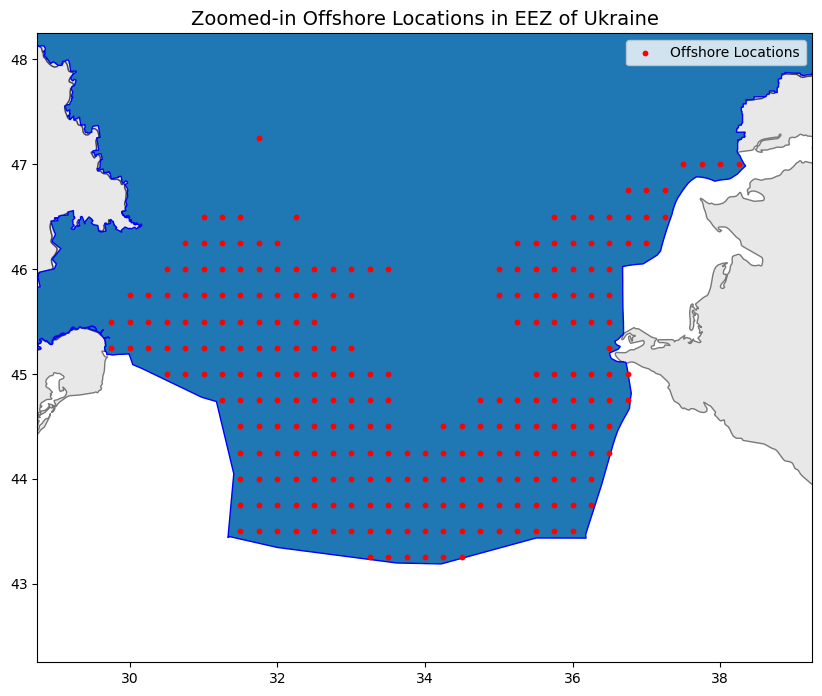

In [15]:
# Does not work for Ukraine example as there are no offshore points detected so EEZ bounds are used instead.

import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point

# Assuming you've already run the earlier code to classify points as offshore or on land

# Step 1: Create a GeoDataFrame for points classified as offshore (MODIS type 18)
offshore_gdf = pv_geodf_with_area[pv_geodf_with_area['primary_land_cover_type'] == 18]
print(offshore_gdf.empty)
print(offshore_gdf)

# Step 2: Get the bounds for zooming in (use the EEZ boundaries and offshore points)
# Combine the EEZ and offshore points bounds to zoom in on the relevant area
combined_bounds = offshore_gdf.total_bounds if not offshore_gdf.empty else country_eez_gdf.total_bounds

# If there are no offshore points, just use the EEZ bounds
if offshore_gdf.empty:
    combined_bounds = country_eez_gdf.total_bounds

# Unpack the bounding box values (xmin, ymin, xmax, ymax)
xmin, ymin, xmax, ymax = combined_bounds

# Step 3: Plot the offshore points and admin boundaries within the zoomed-in area
fig, ax = plt.subplots(figsize=(10, 10))

# Plot the admin boundaries (all countries)
admin_gdf.plot(ax=ax, color='lightgrey', edgecolor='black', alpha=0.5)

# Plot the EEZ boundaries of the country (e.g., Ukraine)
country_eez_gdf.plot(ax=ax, edgecolor='blue', linewidth=1, label='EEZ Boundary')

# Plot the offshore points
offshore_gdf.plot(ax=ax, color='red', markersize=10, label='Offshore Locations')

# Set axis limits based on the bounding box (with some padding for visibility)
ax.set_xlim(xmin - 1, xmax + 1)
ax.set_ylim(ymin - 1, ymax + 1)

# Customize plot labels and title
ax.set_title(f"Zoomed-in Offshore Locations in EEZ of {country}", fontsize=14)
ax.legend()

# Show the plot
plt.show()



In [13]:
print(offshore_gdf.empty, offshore_gdf.shape)
print("offshore bounds:", offshore_gdf.total_bounds, "finite:", np.all(np.isfinite(offshore_gdf.total_bounds)))
print("geom types:", offshore_gdf.geometry.geom_type.unique())
print("any empty geometries:", offshore_gdf.geometry.is_empty.any())
print("CRS: pv_geodf_with_area.crs, admin_gdf.crs, country_eez_gdf.crs")
print("eez present:", None if 'country_eez_gdf' not in globals() else (country_eez_gdf.shape, country_eez_gdf.total_bounds))

True (0, 6)
offshore bounds: [nan nan nan nan] finite: False
geom types: []
any empty geometries: False
CRS: pv_geodf_with_area.crs, admin_gdf.crs, country_eez_gdf.crs
eez present: ((1, 31), array([22.13846564, 43.18805556, 40.21973443, 52.38401413]))


# Plotting

<bound method Series.unique of 0       18.0
1       18.0
2       18.0
3       18.0
4       18.0
        ... 
1427    12.0
1428    10.0
1429    12.0
1430    12.0
1431    12.0
Name: primary_land_cover_type, Length: 1432, dtype: float64>


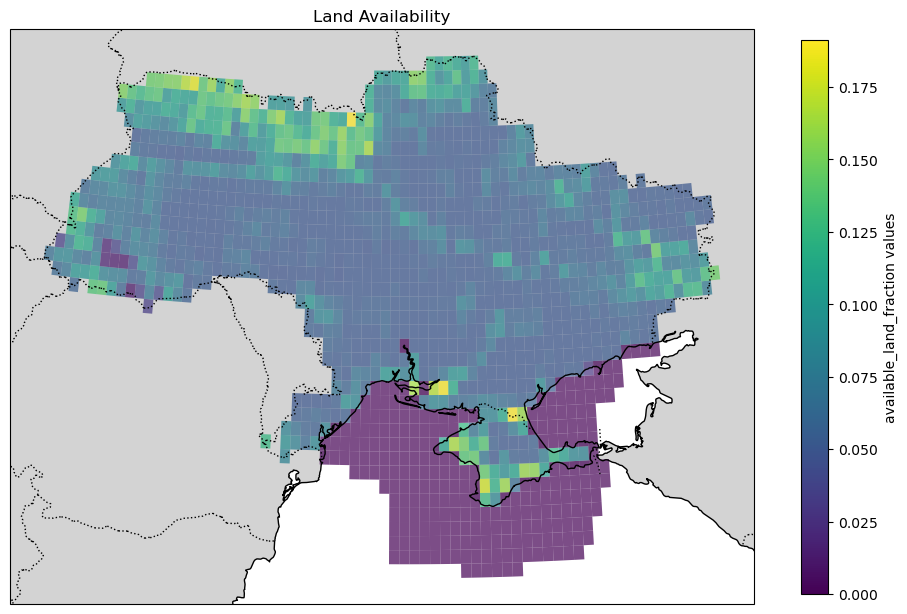

In [13]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from matplotlib.patches import Rectangle
import cartopy.feature as cfeature
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches


# Split the 'location' column into lat/lon directly
pv_geodf_with_area[['lat', 'lon']] = pv_geodf_with_area['location'].str.split('_', expand=True).astype(float)
print((pv_geodf_with_area['primary_land_cover_type'].unique))

# Convert primary_land_cover_type to integer if needed
pv_geodf_with_area['primary_land_cover_type'] = pv_geodf_with_area['primary_land_cover_type'].fillna(17).astype(int)

# Land cover type descriptions (corresponding to the primary land cover types)
land_cover_labels = {
    0: "Water",
    1: "Evergreen Needleleaf Forest",
    2: "Evergreen Broadleaf Forest",
    3: "Deciduous Needleleaf Forest",
    4: "Deciduous Broadleaf Forest",
    5: "Mixed Forests",
    6: "Closed Shrublands",
    7: "Open Shrublands",
    8: "Woody Savannas",
    9: "Savannas",
    10: "Grasslands",
    11: "Permanent Wetlands",
    12: "Croplands",
    13: "Urban and Built-up",
    14: "Cropland/Natural Vegetation Mosaics",
    15: "Snow and Ice",
    16: "Barren or Sparsely Vegetated",
    17: "Unclassified",
    18: "Offshore"  # Add the offshore type
}

# Function for continuous data (like land availability)
def plot_continuous_map(df, title, cmap_name, filename, column):
    # Set up the map projection (Lambert Azimuthal Equal Area)
    projection = ccrs.LambertAzimuthalEqualArea(central_latitude=df['lat'].mean(), central_longitude=df['lon'].mean())
    
    # Create figure and axis
    fig, ax = plt.subplots(figsize=(12, 12), subplot_kw={'projection': projection})

    # Add coastlines, borders, and land features
    ax.add_feature(cfeature.COASTLINE)
    ax.add_feature(cfeature.BORDERS, linestyle=':')
    ax.add_feature(cfeature.LAND, facecolor='lightgray')

    # Add cities using Cartopy's built-in Natural Earth cities dataset
    cities = cfeature.NaturalEarthFeature(category='cultural', name='populated_places', scale='10m')
    ax.add_feature(cities, facecolor='none', edgecolor='black')

    # Choose the colormap and normalization
    cmap = plt.get_cmap(cmap_name)
    norm = plt.Normalize(vmin=df[column].min(), vmax=df[column].max())

    # Plot each grid cell as a rectangle with color based on the continuous value
    for i, row in df.iterrows():
        lat = row['lat']
        lon = row['lon']
        value = row[column]

        # Define the rectangle for the 0.25-degree grid cell
        rect = Rectangle(
            (lon - 0.125, lat - 0.125), 0.25, 0.25,  # lon_min, lat_min, width, height
            facecolor=cmap(norm(value)),  # Color based on normalized value
            edgecolor='none',
            alpha=0.7,
            transform=ccrs.PlateCarree()  # Use PlateCarree for accurate placement
        )
        ax.add_patch(rect)

    # Add colorbar for continuous data
    scatter = ax.scatter(df['lon'], df['lat'], c=df[column], cmap=cmap, s=0, transform=ccrs.PlateCarree(), norm=norm)  # Dummy scatter for colorbar
    cbar = plt.colorbar(
    scatter,
    ax=ax,
    orientation="vertical",
    shrink=0.6,  # 60% of the axes height
    )
    cbar.set_label(f'{column} values')

    # Set title
    plt.title(title)

    # Save the figure as PNG
    plt.savefig(f'{filename}.png')
    plt.show()

# Plot land availability map (continuous data)
plot_continuous_map(
    pv_geodf_with_area, 
    'Land Availability', 
    'viridis', 
    'land_availability_map', 
    column='available_land_fraction'
)


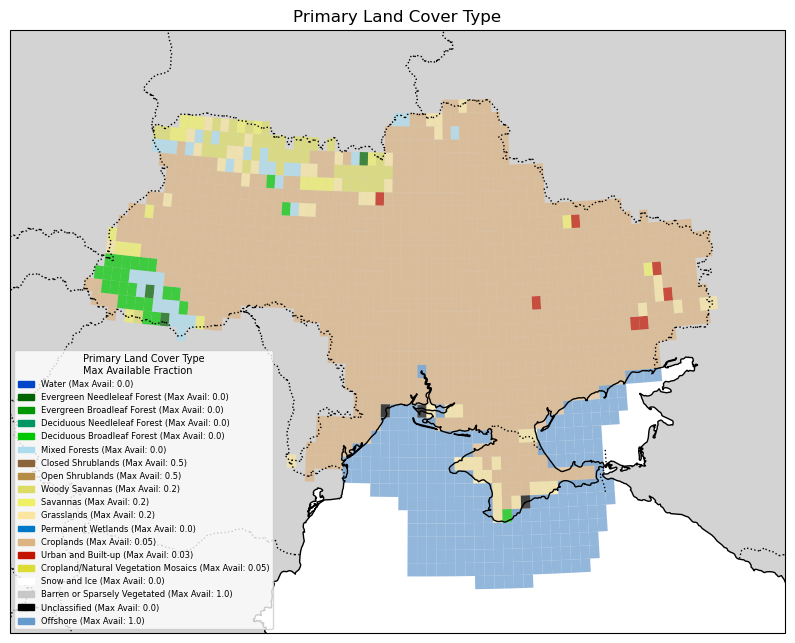

In [17]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from matplotlib.patches import Rectangle
import cartopy.feature as cfeature
import matplotlib.patches as mpatches

# Land cover type descriptions (corresponding to the primary land cover types)
land_cover_labels = {
    0: "Water",
    1: "Evergreen Needleleaf Forest",
    2: "Evergreen Broadleaf Forest",
    3: "Deciduous Needleleaf Forest",
    4: "Deciduous Broadleaf Forest",
    5: "Mixed Forests",
    6: "Closed Shrublands",
    7: "Open Shrublands",
    8: "Woody Savannas",
    9: "Savannas",
    10: "Grasslands",
    11: "Permanent Wetlands",
    12: "Croplands",
    13: "Urban and Built-up",
    14: "Cropland/Natural Vegetation Mosaics",
    15: "Snow and Ice",
    16: "Barren or Sparsely Vegetated",
    17: "Unclassified",
    18: "Offshore"  # Newly added offshore type
}

# Land availability factors for each land cover type
land_availability_factors = {
    0: 0.0,   # Water
    1: 0.0,   # Evergreen Needleleaf Forest
    2: 0.0,   # Evergreen Broadleaf Forest
    3: 0.0,   # Deciduous Needleleaf Forest
    4: 0.0,   # Deciduous Broadleaf Forest
    5: 0.0,   # Mixed Forests
    6: 0.5,   # Closed Shrublands
    7: 0.5,   # Open Shrublands
    8: 0.2,   # Woody Savannas
    9: 0.2,   # Savannas
    10: 0.2,  # Grasslands
    11: 0.0,  # Permanent Wetlands
    12: 0.05, # Croplands
    13: 0.03, # Urban and Built-up
    14: 0.05, # Cropland/Natural Vegetation Mosaics
    15: 0.0,  # Snow and Ice
    16: 1.0,  # Barren or Sparsely Vegetated
    17: 0.0,  # Unclassified
    18: 1.0   # Offshore (newly added)
}

# MODIS color map for each land cover type (based on MODIS IGBP classification)
modis_colors = {
    0: '#0046C8',  # Water
    1: '#006400',  # Evergreen Needleleaf Forest
    2: '#009600',  # Evergreen Broadleaf Forest
    3: '#009664',  # Deciduous Needleleaf Forest
    4: '#00C800',  # Deciduous Broadleaf Forest
    5: '#AADCEE',  # Mixed Forests
    6: '#8C643C',  # Closed Shrublands
    7: '#B48C46',  # Open Shrublands
    8: '#DCDC64',  # Woody Savannas
    9: '#F0F064',  # Savannas
    10: '#FAE6A0', # Grasslands
    11: '#0078C8', # Permanent Wetlands
    12: '#DCB482', # Croplands
    13: '#C31400', # Urban and Built-up
    14: '#DCDC32', # Cropland/Natural Vegetation Mosaics
    15: '#FFFFFF', # Snow and Ice
    16: '#C8C8C8', # Barren or Sparsely Vegetated
    17: '#000000', # Unclassified
    18: '#6699CC'  # Blue-grey color for Offshore (MODIS type 18)
}

# Function for plotting a categorical map with Lambert Azimuthal projection
def plot_categorical_map(df, title, column):
    # Use Lambert Azimuthal Equal Area projection (centralized on the mean lat/lon)
    projection = ccrs.LambertAzimuthalEqualArea(central_latitude=df['lat'].mean(), central_longitude=df['lon'].mean())
    
    # Create figure and axis
    fig, ax = plt.subplots(figsize=(10, 10), subplot_kw={'projection': projection})

    # Add coastlines, borders, and land features for context
    ax.add_feature(cfeature.COASTLINE)
    ax.add_feature(cfeature.BORDERS, linestyle=':')
    ax.add_feature(cfeature.LAND, facecolor='lightgray')

    # Set the map extent to focus on the data area
    ax.set_extent([df['lon'].min() - 1, df['lon'].max() + 1, df['lat'].min() - 1, df['lat'].max() + 1], crs=ccrs.PlateCarree())

    # Plot each point as a rectangle
    for i, row in df.iterrows():
        lat = row['lat']
        lon = row['lon']
        land_cover_type = row[column]

        # Define the rectangle for the 0.25-degree grid cell
        rect = Rectangle(
            (lon - 0.125, lat - 0.125), 0.25, 0.25,  # lon_min, lat_min, width, height
            facecolor=modis_colors[land_cover_type],  # Use MODIS colour map for each category
            edgecolor='none',  # Remove borders from the rectangles
            alpha=0.7,
            transform=ccrs.PlateCarree()  # Use PlateCarree for accurate placement
        )
        ax.add_patch(rect)

    # Create a legend with patches for each land cover type, adjust font size and move it to the bottom left
    legend_patches = [mpatches.Patch(color=modis_colors[i], label=f"{land_cover_labels[i]} (Max Avail: {land_availability_factors[i]})") 
                      for i in land_cover_labels]

    # Add the legend for land cover types and their max available fractions
    ax.legend(handles=legend_patches, loc='lower left', title="Primary Land Cover Type\nMax Available Fraction", fontsize=6, title_fontsize=7)

    # Set title
    plt.title(title)
    plt.show()

# Prepare the 'lat' and 'lon' columns from the 'location' column
pv_geodf_with_area[['lat', 'lon']] = pv_geodf_with_area['location'].str.split('_', expand=True).astype(float)

# Plot the land cover map using Lambert Azimuthal projection with MODIS colors
plot_categorical_map(
    pv_geodf_with_area, 
    'Primary Land Cover Type',  # Updated title
    column='primary_land_cover_type'
)


(2362756.1920872317, 4566882.109794049)


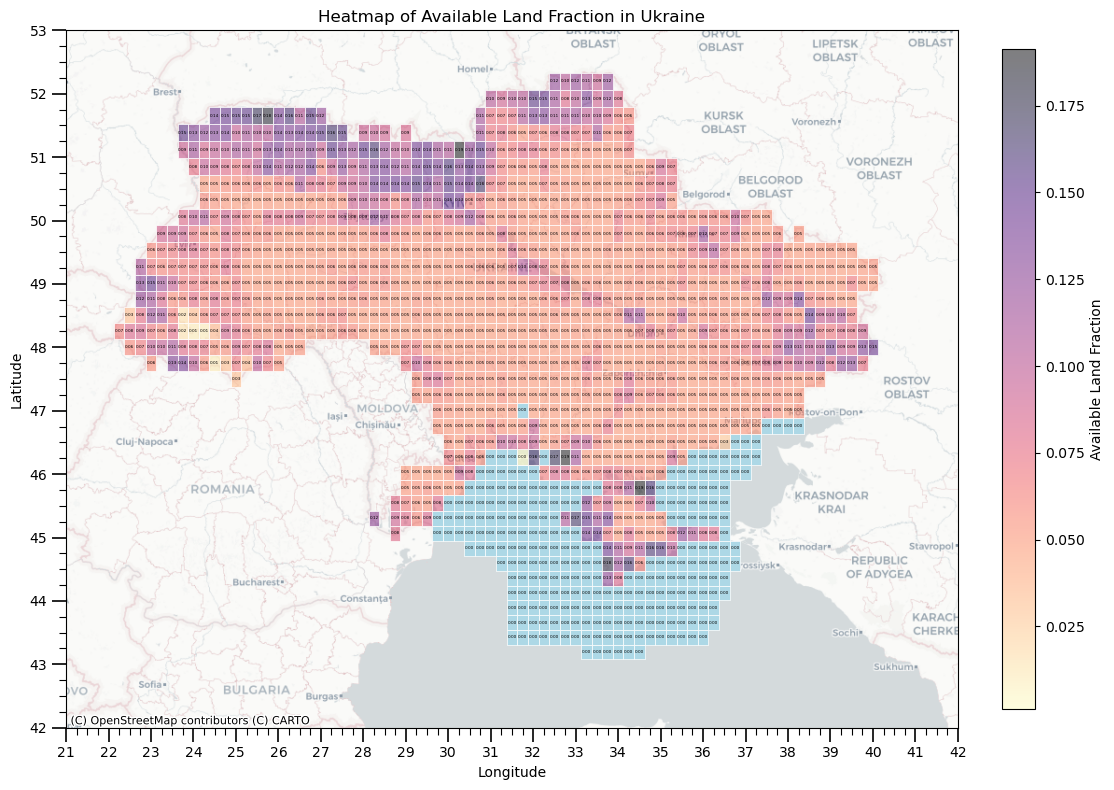

In [18]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Polygon
import numpy as np
from matplotlib.colors import Normalize
from matplotlib import cm
import contextily as ctx  # For basemaps

# Read the CSV file into a DataFrame
land_filename = 'UKR_renewables_land_cover_with_offshore.csv'
file_path = f'../data_prep/data/{land_filename}'
df = pd.read_csv(file_path)

# Split 'location' into 'lat' and 'lon'
df[['lat', 'lon']] = df['location'].str.split('_', expand=True).astype(float)

# Function to create a 0.25-degree rectangle polygon around each point
def create_rectangle(row):
    lon = row['lon']
    lat = row['lat']
    half_size = 0.125  # Half of 0.25 degrees
    # Define the rectangle corners
    coordinates = [
        (lon - half_size, lat - half_size),
        (lon + half_size, lat - half_size),
        (lon + half_size, lat + half_size),
        (lon - half_size, lat + half_size),
        (lon - half_size, lat - half_size)  # Close the polygon
    ]
    return Polygon(coordinates)

# Create a geometry column with rectangle polygons
df['geometry'] = df.apply(create_rectangle, axis=1)

# Convert the DataFrame to a GeoDataFrame and set the CRS
gdf = gpd.GeoDataFrame(df, geometry='geometry', crs='EPSG:4326')  # Latitude/Longitude CRS

# Clean all numeric columns to ensure no non-finite values
for column in gdf.select_dtypes(include=[np.number]).columns:
    gdf[column] = pd.to_numeric(gdf[column], errors='coerce')  # Coerce errors to NaN
    gdf[column] = gdf[column].replace([np.inf, -np.inf], np.nan).fillna(0)  # Replace inf and NaN with 0

# Exclude rows with primary_land_cover_type == 18
gdf_excluded = gdf[gdf['primary_land_cover_type'] == 18]
gdf_included = gdf[gdf['primary_land_cover_type'] != 18]

# Normalize available_land_fraction for color scaling
min_bound = gdf_included['available_land_fraction'].min()
max_bound = gdf_included['available_land_fraction'].max()
norm = Normalize(vmin=min_bound, vmax=max_bound)

# Create a reversed magma colormap with transparency
cmap = cm.magma_r  # Reversed magma colormap
transparent_cmap = cmap(np.linspace(0, 1, 256))  # Create an RGBA array from the colormap
transparent_cmap[:, 3] = 0.5  # Set alpha channel (index 3) to 0.5 for transparency
transparent_cmap = cm.colors.ListedColormap(transparent_cmap)  # Convert back to colormap

# Reproject to Web Mercator for basemap
gdf_web_mercator_included = gdf_included.to_crs(epsg=3857)
gdf_web_mercator_excluded = gdf_excluded.to_crs(epsg=3857)

# Plot the map
fig, ax = plt.subplots(figsize=(12, 8))

# Plot excluded cells with pale blue color
gdf_web_mercator_excluded.plot(
    ax=ax,
    color='lightblue',
    edgecolor='white',
    linewidth=0.5
)

# Plot included cells with the colormap and transparency
gdf_web_mercator_included.plot(
    ax=ax,
    column='available_land_fraction',
    cmap=transparent_cmap,
    norm=norm,
    edgecolor='white',
    linewidth=0.5
)

# Add labels to included cells
for idx, row in gdf_web_mercator_included.iterrows():
    plt.annotate(
        text=f"{row['available_land_fraction']:.2f}",
        xy=(row['geometry'].centroid.x, row['geometry'].centroid.y),
        ha='center',
        va='center',
        fontsize=3  # Small font size for labels
    )

# Add labels to excluded cells
for idx, row in gdf_web_mercator_excluded.iterrows():
    plt.annotate(
        text=f"{row['available_land_fraction']:.2f}",
        xy=(row['geometry'].centroid.x, row['geometry'].centroid.y),
        ha='center',
        va='center',
        fontsize=3  # Small font size for labels
    )

# Add a basemap
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, zoom=6)

# Get the bounds in Web Mercator
xlim = ax.get_xlim()
ylim = ax.get_ylim()

print(xlim)

# Convert bounds to latitude/longitude for ticks
def mercator_to_lonlat(x, y):
    """Convert Web Mercator (EPSG:3857) coordinates to latitude/longitude."""
    lon = x * 180.0 / 20037508.34
    lat = (2 * np.arctan(np.exp(y * np.pi / 20037508.34)) - np.pi / 2) * 180.0 / np.pi
    return lon, lat

# Define major (labelled) and minor ticks
lon_start, lon_end = mercator_to_lonlat(xlim[0], 0)[0], mercator_to_lonlat(xlim[1], 0)[0]
lat_start, lat_end = mercator_to_lonlat(0, ylim[0])[1], mercator_to_lonlat(0, ylim[1])[1]

# Major ticks (labelled): Whole degrees
lon_major = np.arange(np.floor(lon_start), np.ceil(lon_end) + 1, 1.0)
lat_major = np.arange(np.floor(lat_start), np.ceil(lat_end) + 1, 1.0)

# Minor ticks (unlabelled): 0.25-degree intervals
lon_minor = np.arange(np.floor(lon_start), np.ceil(lon_end) + 0.25, 0.25)
lat_minor = np.arange(np.floor(lat_start), np.ceil(lat_end) + 0.25, 0.25)

# Convert ticks back to Web Mercator
lon_major_merc = [xlim[0] + (lon - lon_start) * (xlim[1] - xlim[0]) / (lon_end - lon_start) for lon in lon_major]
lat_major_merc = [ylim[0] + (lat - lat_start) * (ylim[1] - ylim[0]) / (lat_end - lat_start) for lat in lat_major]
lon_minor_merc = [xlim[0] + (lon - lon_start) * (xlim[1] - xlim[0]) / (lon_end - lon_start) for lon in lon_minor]
lat_minor_merc = [ylim[0] + (lat - lat_start) * (ylim[1] - ylim[0]) / (lat_end - lat_start) for lat in lat_minor]


# Set ticks on axes
ax.set_xticks(lon_major_merc, minor=False)  # Major ticks
ax.set_xticks(lon_minor_merc, minor=True)  # Minor ticks
ax.set_yticks(lat_major_merc, minor=False)  # Major ticks
ax.set_yticks(lat_minor_merc, minor=True)  # Minor ticks

# Set tick labels for major ticks only
ax.set_xticklabels([f"{lon:.0f}" for lon in lon_major])
ax.set_yticklabels([f"{lat:.0f}" for lat in lat_major])

# Set tick styles
ax.tick_params(axis='both', which='major', length=10, width=1.2)  # Major ticks
ax.tick_params(axis='both', which='minor', length=5, width=0.8)  # Minor ticks

# Add axis labels
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

# Add a colorbar with transparency
sm = cm.ScalarMappable(cmap=transparent_cmap, norm=norm)
sm._A = []  # Required for ScalarMappable to work with colorbar
cbar = fig.colorbar(sm, ax=ax, orientation='vertical', fraction=0.03, pad=0.04)
cbar.set_label('Available Land Fraction')

# Set map details
ax.set_title('Heatmap of Available Land Fraction in Ukraine')

# Adjust layout and show the plot
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd

combined_df = pd.read_csv('../data_prep/data/UKR_renewables_land_cover_with_offshore.csv')
combined_df = combined_df[['location', 'area_km2', 'available_land_area_km2', 'available_land_fraction']].copy()
combined_df[['lat', 'lon']] = combined_df['location'].str.split('_', expand=True).astype(float)


# Load CF profiles with datetime as index
wind_df = pd.read_csv('../data_prep/era5_data/UKR_wind_power_profile.csv', index_col=0, parse_dates=True)
solar_df = pd.read_csv('../data_prep/era5_data/UKR_solar_power_profile.csv', index_col=0, parse_dates=True)
pc_df = pd.read_csv('data/UKR_wind_solar_PCs.csv')
pc_df = pc_df[['location', 'pc1', 'pc2', 'pc3']].copy()

# Ensure numeric columns only (coerce non-numeric to NaN, then drop all-NaN columns if any)
wind_df = wind_df.apply(pd.to_numeric, errors='coerce')
solar_df = solar_df.apply(pd.to_numeric, errors='coerce')

# Annual averages by location (columns are locations)
wind_avg = wind_df.mean().reset_index()
wind_avg.columns = ['location', 'wind_cf']

solar_avg = solar_df.mean().reset_index()
solar_avg.columns = ['location', 'solar_cf']

# Merge
combined_df = combined_df.merge(wind_avg, on='location', how='left')
combined_df = combined_df.merge(solar_avg, on='location', how='left')
combined_df = combined_df.merge(pc_df, on='location', how='left')


# Reorder/rename
combined_df = combined_df[['lon', 'lat', 'wind_cf', 'solar_cf', 'area_km2' , 'available_land_area_km2', 'available_land_fraction', 'pc1', 'pc2', 'pc3']]
combined_df.columns = ['lon', 'lat', 'wind_cf', 'solar_cf', 'area', 'available_land_area', 'availability_fraction', 'pc1', 'pc2', 'pc3']

# Save
combined_df.to_csv('../data_prep/data/UKR_combined_renewables_land_availability.csv', index=False)
print("Combined dataframe saved successfully!")
print(combined_df.head())



Combined dataframe saved successfully!
     lon    lat   wind_cf  solar_cf        area  available_land_area  \
0  28.75  45.25  0.220876  0.149312  545.286049            43.815785   
1  28.25  45.50  0.206970  0.147582  542.912573            67.442028   
2  28.50  45.50       NaN       NaN  542.912573            72.562433   
3  28.75  45.50  0.223316  0.146742  542.912573            50.175000   
4  29.00  45.50  0.225695  0.147045  542.912573            43.643629   

   availability_fraction        pc1        pc2        pc3  
0               0.080354   8.018624  56.152690 -42.602603  
1               0.124223  13.937854  52.376710 -42.753363  
2               0.133654        NaN        NaN        NaN  
3               0.092418   8.646302  54.863333 -44.237482  
4               0.080388   5.784859  56.124634 -44.783791  


In [21]:
# I want to trim the wind and solar cf profiles so that they only include locations 
# present in the'data/ukraine_merged_dissolved_noholes.geojson'.

# Trim wind/solar CF profiles to locations within Ukraine boundary

import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
from shapely.geometry import box

# Paths
geojson_path = "data/ukraine_merged_dissolved_noholes.geojson"
wind_in = "era5_data/UKR_wind_power_profile.csv"
solar_in = "era5_data/UKR_solar_power_profile.csv"

wind_out = "era5_data/UKR_wind_power_profile_trimmed.csv"
solar_out = "era5_data/UKR_solar_power_profile_trimmed.csv"

# Load Ukraine geometry
ukr = gpd.read_file(geojson_path).to_crs("EPSG:4326")
ukr = ukr.dissolve()  # ensure single polygon

def trim_profile_columns(csv_path, out_path):
    df = pd.read_csv(csv_path, index_col=0, parse_dates=True)

    # Columns are locations like "lat_lon"
    locations = pd.Index(df.columns, name="location")
    lat_lon = locations.to_series().str.split("_", expand=True)

    loc_df = pd.DataFrame({
        "location": locations,
        "lat": lat_lon[0].astype(float).values,
        "lon": lat_lon[1].astype(float).values,
    })

    gdf = gpd.GeoDataFrame(
        loc_df,
        geometry=gpd.points_from_xy(loc_df["lon"], loc_df["lat"]),
        crs="EPSG:4326",
    )

    half_cell = 0.125  # 0.25 / 2

    # include border points using intersects
    keep = gpd.sjoin(gdf, ukr, how="inner", predicate="intersects")
    print(f"keep after sjoin - geometry type: {keep.geometry.type.unique()}")
    print(f"Trimmed to {len(keep)} cells")
    
    keep['geometry'] = keep.geometry.apply(
        lambda point: box(point.x - half_cell, point.y - half_cell, 
                      point.x + half_cell, point.y + half_cell)
    )
    
    print(f"After conversion - geometry type: {keep.geometry.type.unique()}")
    
    # Save the trimmed GeoDataFrame with geometries to GeoJSON
    geojson_output_path = "data/UKR_solar_power_profile_trimmed.geojson"
    keep.to_file(geojson_output_path, driver="GeoJSON")
    print(f"Trimmed GeoJSON saved to {geojson_output_path}")
    
    keep_locations = keep["location"].tolist()
    
    df_trim = df.loc[:, df.columns.isin(keep_locations)]
    df_trim.to_csv(out_path, index_label="datetime")
    return df_trim

wind_trimmed = trim_profile_columns(wind_in, wind_out)
solar_trimmed = trim_profile_columns(solar_in, solar_out)

print(wind_trimmed.shape[1], solar_trimmed.shape[1])

keep after sjoin - geometry type: ['Point']
Trimmed to 1180 cells
After conversion - geometry type: ['Polygon']
Trimmed GeoJSON saved to data/UKR_solar_power_profile_trimmed.geojson
keep after sjoin - geometry type: ['Point']
Trimmed to 1180 cells
After conversion - geometry type: ['Polygon']
Trimmed GeoJSON saved to data/UKR_solar_power_profile_trimmed.geojson
1180 1180


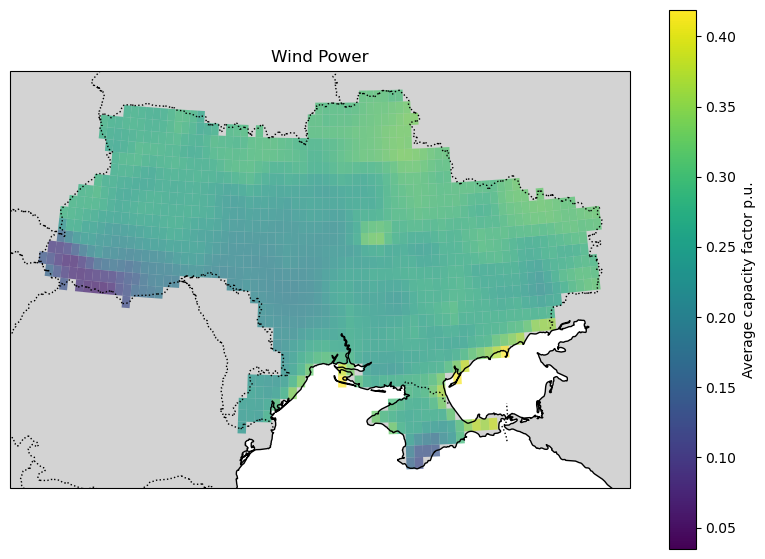

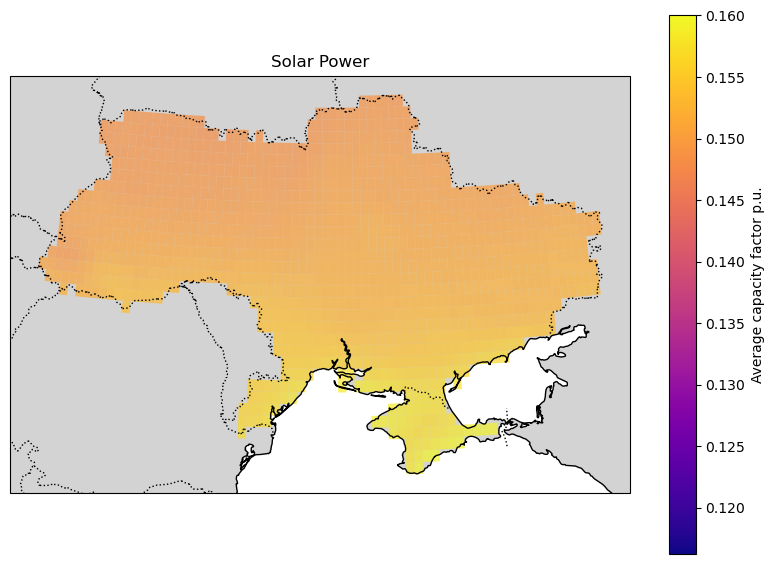

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from matplotlib.patches import Rectangle
import cartopy.feature as cfeature

# Function to get the average values from the CSV files
def get_avg_values(power_df):
    avg_df = power_df.mean(axis=0).reset_index()
    avg_df.columns = ['location', 'avg_power']
    avg_df[['lat', 'lon']] = avg_df['location'].str.split('_', expand=True).astype(float)
    return avg_df

# Define the paths to the power profile files (0.25-degree resolution)
save_path = './era5_data'
iso3_code = 'UKR'

# Get the average values for wind and solar power
wind_avg = get_avg_values(wind_trimmed)
solar_avg = get_avg_values(solar_trimmed)

# Function to plot the data using Cartopy with Lambert Azimuthal Equal Area projection
def plot_static_map(df, title, cmap_name, filename):
    # Set up the map projection (Lambert Azimuthal Equal Area)
    projection = ccrs.LambertAzimuthalEqualArea(central_latitude=df['lat'].mean(), central_longitude=df['lon'].mean())
    
    # Create figure and axis
    fig, ax = plt.subplots(figsize=(10, 7), subplot_kw={'projection': projection})

    # Add coastlines, borders, and land features
    ax.add_feature(cfeature.COASTLINE)
    ax.add_feature(cfeature.BORDERS, linestyle=':')
    ax.add_feature(cfeature.LAND, facecolor='lightgray')

    # Use the new colormap API introduced in Matplotlib 3.7+
    cmap = plt.colormaps.get_cmap(cmap_name)

    # Loop over the DataFrame rows to plot each grid cell
    for i, row in df.iterrows():
        lat = row['lat']
        lon = row['lon']
        avg_power = row['avg_power']
        
        
        # Define the rectangle for the 0.25-degree grid cell
        rect = Rectangle(
            (lon - 0.125, lat - 0.125), 0.25, 0.25,  # lon_min, lat_min, width, height
            facecolor=cmap(avg_power / df['avg_power'].max()),  # Color based on avg power
            edgecolor='none',
            alpha=0.7,
            transform=ccrs.PlateCarree()  # Use PlateCarree for accurate placement
        )
        ax.add_patch(rect)

    # Add colorbar
    scatter = ax.scatter(df['lon'], df['lat'], c=df['avg_power'], cmap=cmap_name, s=0, transform=ccrs.PlateCarree())  # Dummy scatter for colorbar
    cbar = plt.colorbar(scatter, ax=ax, orientation="vertical")
    cbar.set_label('Average capacity factor p.u.')
    
    # Set title
    plt.title(title)

    # Save the figure as PNG
    plt.savefig(f'{filename}.png')
    plt.show()

# Plot the wind power map
plot_static_map(wind_avg, 'Wind Power', 'viridis', 'wind_power_map_1')

# Plot the solar power map
plot_static_map(solar_avg, 'Solar Power', 'plasma', 'solar_power_map_1')

In [1]:
import pandas as pd
import geopandas as gpd

# Paths
geojson_path = "data/ukraine_merged_dissolved_noholes.geojson"
avail_in = "../data_prep/data/UKR_renewables_land_cover_with_offshore.csv"
avail_out = "../data_prep/data/UKR_renewables_land_cover_with_offshore_trimmed.csv"

# Load availability data (format: location, area_km2, available_land_fraction, available_land_area_km2, primary_land_cover_type)
df = pd.read_csv(avail_in)

# Parse lat/lon from "lat_lon" location
loc_split = df["location"].str.split("_", expand=True).astype(float)
df["lat"] = loc_split[0]
df["lon"] = loc_split[1]

# GeoDataFrame of points
gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df["lon"], df["lat"]),
    crs="EPSG:4326",
)

# Load Ukraine geometry and dissolve to single polygon
ukr = gpd.read_file(geojson_path).to_crs("EPSG:4326").dissolve()

# Keep points that intersect the polygon (includes border points)
keep = gpd.sjoin(gdf, ukr, how="inner", predicate="intersects")

# Drop geometry + helper columns and save
keep = keep.drop(columns=["geometry", "index_right", "lat", "lon"], errors="ignore")
keep.to_csv(avail_out, index=False)

print("Trimmed rows:", len(keep))

Trimmed rows: 1180


<bound method Series.unique of 95      10
96       4
117     10
118     12
119     10
        ..
1427    12
1428    10
1429    12
1430    12
1431    12
Name: primary_land_cover_type, Length: 1180, dtype: int32>


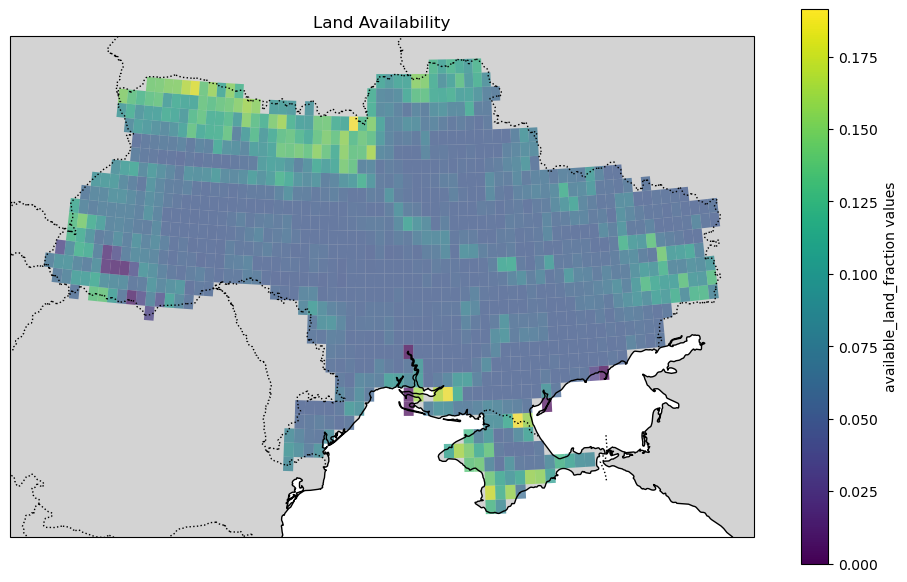

In [4]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from matplotlib.patches import Rectangle
import cartopy.feature as cfeature
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches

# Split the 'location' column into lat/lon directly
keep[['lat', 'lon']] = keep['location'].str.split('_', expand=True).astype(float)
print((keep['primary_land_cover_type'].unique))

# Convert primary_land_cover_type to integer if needed
keep['primary_land_cover_type'] = keep['primary_land_cover_type'].fillna(17).astype(int)

# Land cover type descriptions (corresponding to the primary land cover types)
land_cover_labels = {
    0: "Water",
    1: "Evergreen Needleleaf Forest",
    2: "Evergreen Broadleaf Forest",
    3: "Deciduous Needleleaf Forest",
    4: "Deciduous Broadleaf Forest",
    5: "Mixed Forests",
    6: "Closed Shrublands",
    7: "Open Shrublands",
    8: "Woody Savannas",
    9: "Savannas",
    10: "Grasslands",
    11: "Permanent Wetlands",
    12: "Croplands",
    13: "Urban and Built-up",
    14: "Cropland/Natural Vegetation Mosaics",
    15: "Snow and Ice",
    16: "Barren or Sparsely Vegetated",
    17: "Unclassified",
    18: "Offshore"  # Add the offshore type
}

# Function for continuous data (like land availability)
def plot_continuous_map(df, title, cmap_name, filename, column):
    # Set up the map projection (Lambert Azimuthal Equal Area)
    projection = ccrs.LambertAzimuthalEqualArea(central_latitude=df['lat'].mean(), central_longitude=df['lon'].mean())
    
    # Create figure and axis
    fig, ax = plt.subplots(figsize=(12, 12), subplot_kw={'projection': projection})

    # Add coastlines, borders, and land features
    ax.add_feature(cfeature.COASTLINE)
    ax.add_feature(cfeature.BORDERS, linestyle=':')
    ax.add_feature(cfeature.LAND, facecolor='lightgray')

    # Add cities using Cartopy's built-in Natural Earth cities dataset
    cities = cfeature.NaturalEarthFeature(category='cultural', name='populated_places', scale='10m')
    ax.add_feature(cities, facecolor='none', edgecolor='black')

    # Choose the colormap and normalization
    cmap = plt.get_cmap(cmap_name)
    norm = plt.Normalize(vmin=df[column].min(), vmax=df[column].max())

    # Plot each grid cell as a rectangle with color based on the continuous value
    for i, row in df.iterrows():
        lat = row['lat']
        lon = row['lon']
        value = row[column]

        # Define the rectangle for the 0.25-degree grid cell
        rect = Rectangle(
            (lon - 0.125, lat - 0.125), 0.25, 0.25,  # lon_min, lat_min, width, height
            facecolor=cmap(norm(value)),  # Color based on normalized value
            edgecolor='none',
            alpha=0.7,
            transform=ccrs.PlateCarree()  # Use PlateCarree for accurate placement
        )
        ax.add_patch(rect)

    # Add colorbar for continuous data
    scatter = ax.scatter(df['lon'], df['lat'], c=df[column], cmap=cmap, s=0, transform=ccrs.PlateCarree(), norm=norm)  # Dummy scatter for colorbar
    cbar = plt.colorbar(
    scatter,
    ax=ax,
    orientation="vertical",
    shrink=0.6,  # 60% of the axes height
    )   
    cbar.set_label(f'{column} values')

    # Set title
    plt.title(title)

    # Save the figure as PNG
    plt.savefig(f'{filename}.png')
    plt.show()

# Plot land availability map (continuous data)
plot_continuous_map(
    keep, 
    'Land Availability', 
    'viridis', 
    'land_availability_map', 
    column='available_land_fraction'
)